[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ImagingDataCommons/idc-monai/blob/main/monai_contribution/idc_dataset.ipynb)

# Using NCI Imaging Data Commons with MONAI

Copyright 2026 Imaging Data Commons

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0

---

This tutorial demonstrates how to use imaging data from the [NCI Imaging Data Commons (IDC)](https://portal.imaging.datacommons.cancer.gov/) with MONAI for medical imaging AI tasks.

This tutorial was created using [idc-claude-skill](https://github.com/ImagingDataCommons/idc-claude-skill) - use it to simplify the use of `idc-index` package and understand how IDC works!

**IDC** is a cloud-based repository of publicly available cancer imaging data with:
- ~100 TB of radiology and pathology images
- No authentication required for access
- AI-generated and expert annotations
- All data in DICOM format

## Setup environment

In [1]:
!pip install -q monai idc-index itk itkwasm-dicom

# Restart runtime after installing ITK (required for ITK to load properly)
import sys
if "google.colab" in sys.modules:
    try:
        import itk
    except ImportError:
        print("Restarting runtime to load ITK...")
        import os
        os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.1/74.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.7 

## Setup imports

In [2]:
import os
import tempfile
from pathlib import Path
from typing import Hashable, Mapping

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from idc_index import IDCClient

from monai.config import KeysCollection
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    MapTransform,
)
from monai.data import Dataset, DataLoader, MetaTensor
from monai.data.image_reader import ITKReader
import monai

monai.config.print_config()

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.6
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.25.0+cpu
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installin

## 1. Query IDC Data

Use `idc-index` to query IDC's metadata index using SQL.

In [3]:
# Initialize IDC client
client = IDCClient()

# Check IDC version and data scale
print(f"IDC version: {client.get_idc_version()}")

stats = client.sql_query("""
    SELECT COUNT(DISTINCT collection_id) as collections,
           COUNT(DISTINCT PatientID) as patients
    FROM index
""")
print(f"Collections: {stats.iloc[0]['collections']}, Patients: {stats.iloc[0]['patients']}")

IDC version: v23
Collections: 161, Patients: 79569


In [4]:
# Find lung CT collections by joining collections_index with index
client.fetch_index("collections_index")

# Join to get modality information (not available in collections_index directly)
lung_collections = client.sql_query("""
    SELECT c.collection_id, c.Subjects, c.CancerTypes,
           COUNT(DISTINCT CASE WHEN i.Modality = 'CT' THEN i.SeriesInstanceUID END) as ct_series
    FROM collections_index c
    JOIN index i ON c.collection_id = i.collection_id
    WHERE c.CancerTypes LIKE '%Lung%'
    GROUP BY c.collection_id, c.Subjects, c.CancerTypes
    HAVING ct_series > 0
    ORDER BY c.Subjects DESC
    LIMIT 5
""")
print("Lung CT collections:")
print(lung_collections.to_string(index=False))

Lung CT collections:
             collection_id  Subjects                                                                                                                                                                                                      CancerTypes  ct_series
                      nlst     26410                                                                                                                                                                                          Lung Cancer, Non-Cancer     203087
                 lidc_idri      1010                                                                                                                                                                      Lung Cancer, Non-Cancer, Metastatic disease       1018
                 tcga_luad       560                                                                                                                                                                            

In [22]:
client.fetch_index("volume_geometry_index")

# Query specific CT series (using small rider_pilot collection for demo)
series_df = client.sql_query("""
    SELECT index.SeriesInstanceUID, PatientID, Modality,
           ROUND(series_size_MB, 2) as size_mb
    FROM index
    JOIN volume_geometry_index USING (SeriesInstanceUID)
    WHERE regularly_spaced_3d_volume = TRUE AND Modality = 'CT'
    LIMIT 3
""")
print(f"Found {len(series_df)} CT series")

Found 3 CT series


## 2. Download DICOM Data

In [23]:
# Download to temporary directory
data_dir = tempfile.mkdtemp(prefix="idc_monai_")
series_uids = list(series_df['SeriesInstanceUID'])

print(f"Downloading {len(series_uids)} series...")
client.download_from_selection(
    seriesInstanceUID=series_uids,
    downloadDir=data_dir,
    dirTemplate="%SeriesInstanceUID"
)
print("Done!")

Done!


## 3. Load with MONAI Transforms

MONAI's `LoadImaged` with `ITKReader` directly loads DICOM series from directories.

In [24]:
# Define transforms for CT preprocessing
# Use ITKReader explicitly to load DICOM series from directories
transforms = Compose([
    LoadImaged(keys=["image"], reader=ITKReader()),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0)),
    ScaleIntensityRanged(keys=["image"], a_min=-175, a_max=250,
                         b_min=0.0, b_max=1.0, clip=True),
])

# Create dataset
data_dicts = [{"image": os.path.join(data_dir, uid)} for uid in series_uids]
dataset = Dataset(data=data_dicts, transform=transforms)

# Load sample
sample = dataset[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Value range: [{sample['image'].min():.2f}, {sample['image'].max():.2f}]")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


Image shape: torch.Size([1, 280, 280, 171])
Value range: [0.00, 1.00]


## 4. Visualize

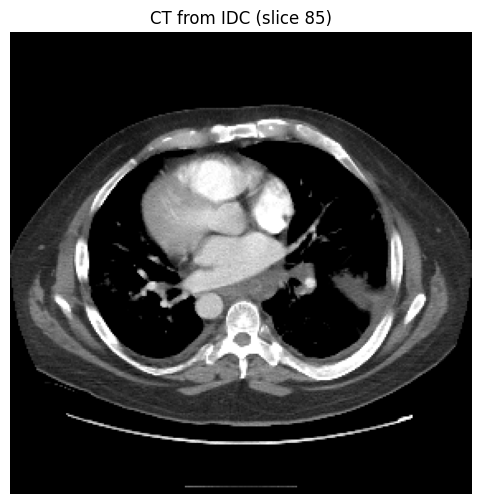

In [25]:

image = sample['image'][0]
z = image.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(image[:, :, z].T, cmap='gray', origin='lower')
plt.title(f'CT from IDC (slice {z})')
plt.axis('off')
plt.show()


## 5. Loading DICOM Segmentations

IDC contains DICOM Segmentation (DICOM-SEG) objects. These are different from regular DICOM series:
- **Enhanced multiframe**: All slices in a single file
- **Cannot use ITKReader**: Standard readers don't support this format
- **Segment metadata**: Each segment has label, description, and recommended display color

We define a custom `LoadDicomSegd` transform that:
1. Uses `itkwasm-dicom` (wraps dcmqi) for robust DICOM-SEG reading
2. Derives the affine matrix directly from DICOM metadata (direction cosines, spacing, origin) — no axis flipping
3. Orientation is fully encoded in the affine via the direction cosine matrix
4. Extracts segment colors from DICOM metadata for visualization

> **Note**: CT and SEG may have different affines when acquired with different orientations (common with AI-generated segmentations like TotalSegmentator). Apply `Orientationd` to normalize both to a common orientation before voxel-level overlay.

In [26]:
# Fetch seg_index to find paired image-segmentation data
client.fetch_index("seg_index")

# Find CT with TotalSegmentator segmentations (104 anatomical structures)
paired = client.sql_query("""
    SELECT src.SeriesInstanceUID as image_uid,
           seg.SeriesInstanceUID as seg_uid,
           src.collection_id, seg.total_segments,
           ROUND(src.series_size_MB, 2) as image_mb
    FROM seg_index seg
    JOIN index src ON seg.segmented_SeriesInstanceUID = src.SeriesInstanceUID
    WHERE src.Modality = 'CT'
      AND seg.AlgorithmName LIKE '%TotalSegmentator%'
    ORDER BY src.series_size_MB ASC
    LIMIT 3
""")
print("CT with TotalSegmentator segmentations:")
print(paired.to_string(index=False))

CT with TotalSegmentator segmentations:
                                                  image_uid                                                   seg_uid collection_id  total_segments  image_mb
 1.2.840.113654.2.55.39501032054040159252741883490811009228 1.2.276.0.7230010.3.1.3.313263360.23926.1706319815.161829          nlst              47     26.32
1.2.840.113654.2.55.134877680474542655199243531560181528016 1.2.276.0.7230010.3.1.3.313263360.31910.1706312185.595733          nlst              73     26.32
1.2.840.113654.2.55.296129646159215067393462057349853219678 1.2.276.0.7230010.3.1.3.313263360.35421.1706312631.378111          nlst              62     26.32


In [27]:
# Download one image-segmentation pair
demo_pair = paired.iloc[0]
seg_dir = tempfile.mkdtemp(prefix="idc_seg_")

print(f"Downloading image and segmentation pair...")
client.download_from_selection(
    seriesInstanceUID=[demo_pair['image_uid'], demo_pair['seg_uid']],
    downloadDir=seg_dir,
    dirTemplate="%SeriesInstanceUID"
)
print("Done!")

Done!


In [29]:
import itkwasm_dicom

class LoadDicomSegd(MapTransform):
    """Load DICOM Segmentation (DICOM-SEG) files using ITKWasm.

    DICOM-SEG is an enhanced multiframe DICOM format that stores segmentation
    masks with segment metadata including recommended display colors.

    The affine matrix is derived directly from DICOM metadata (direction cosines,
    spacing, origin) with LPS→RAS conversion applied to match MONAI's ITKReader
    convention. No axis flipping is performed — orientation is fully encoded in
    the affine via the direction cosine matrix.
    """

    def __init__(self, keys: KeysCollection, allow_missing_keys: bool = False):
        super().__init__(keys, allow_missing_keys)

    def _find_dcm_file(self, path: Path) -> Path:
        """Find .dcm file in directory or return path if already a file."""
        if path.is_file():
            return path
        dcm_files = list(path.glob("*.dcm"))
        if not dcm_files:
            raise FileNotFoundError(f"No .dcm files found in {path}")
        return dcm_files[0]

    def _build_affine(self, spacing, origin, direction) -> np.ndarray:
        """Build 4x4 affine matrix from DICOM spatial metadata.

        Converts from ITK/DICOM LPS convention to MONAI's RAS-like convention
        by negating X and Y world coordinates (LPS→RAS). No axis flips are
        applied — orientation is fully encoded in the affine via the direction
        cosine matrix.

        Args:
            spacing:   Voxel spacing (X, Y, Z) as returned by itkwasm
            origin:    Physical coordinates of voxel [0,0,0] in LPS
            direction: 3x3 direction cosine matrix D where D[i,j] is the
                       component of voxel-axis-j's unit vector along LPS
                       physical axis i. ITK affine formula:
                       world_lps = D @ diag(spacing) @ voxel + origin
        """
        lps_to_ras = np.diag([-1., -1., 1.])
        affine = np.eye(4)
        affine[:3, :3] = lps_to_ras @ direction @ np.diag(spacing)
        affine[:3, 3] = lps_to_ras @ origin
        return affine

    def __call__(self, data: Mapping[Hashable, any]) -> dict[Hashable, any]:
        d = dict(data)
        for key in self.key_iterator(d):
            path = Path(d[key])
            dcm_file = self._find_dcm_file(path)

            # Read using ITKWasm
            seg_image, overlay_info = itkwasm_dicom.read_segmentation(dcm_file)

            # ITKWasm returns array in (Z, Y, X) order but metadata in (X, Y, Z) order.
            # Transpose to (X, Y, Z) to match metadata — this is a layout convention,
            # not an orientation flip.
            seg_array = np.asarray(seg_image.data).copy()
            seg_array = np.transpose(seg_array, (2, 1, 0))

            # Build affine from spatial metadata
            spacing = np.array(seg_image.spacing)
            origin = np.array(seg_image.origin)
            direction = np.array(seg_image.direction).reshape(3, 3)

            affine = self._build_affine(spacing, origin, direction)

            # Make contiguous (array may be non-contiguous after transpose)
            seg_array = np.ascontiguousarray(seg_array)

            # Create MONAI MetaTensor with metadata
            meta_tensor = MetaTensor(seg_array)
            meta_tensor.affine = affine
            meta_tensor.meta["filename_or_obj"] = str(dcm_file)
            meta_tensor.meta["overlay_info"] = overlay_info
            meta_tensor.meta["original_channel_dim"] = "no_channel"

            d[key] = meta_tensor
            d[f"{key}_meta_dict"] = dict(meta_tensor.meta)

        return d

# Load CT with MONAI's ITKReader
ct_transforms = Compose([
    LoadImaged(keys=["image"], reader=ITKReader()),
    EnsureChannelFirstd(keys=["image"]),
])

# Load SEG with our custom LoadDicomSegd
seg_transforms = Compose([
    LoadDicomSegd(keys=["label"]),
    EnsureChannelFirstd(keys=["label"]),
])

# Load both
image_path = os.path.join(seg_dir, demo_pair['image_uid'])
seg_path = os.path.join(seg_dir, demo_pair['seg_uid'])

ct_data = ct_transforms({"image": image_path})
seg_data = seg_transforms({"label": seg_path})

ct_image = ct_data["image"]
seg_label = seg_data["label"]

print(f"CT image shape: {ct_image.shape}")
print(f"Segmentation shape: {seg_label.shape}")
print(f"Unique labels: {torch.unique(seg_label)[:10].tolist()}...")  # First 10 labels

CT image shape: torch.Size([1, 512, 512, 50])
Segmentation shape: torch.Size([1, 512, 512, 50])
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


In [30]:
# Print affines — they may differ when CT and SEG have different direction matrices.
# Both are correct: each faithfully encodes the spatial metadata from its DICOM file.
# Use Orientationd to normalize to a common orientation before voxel-level overlay.
print("CT affine:")
print(ct_image.affine)
print("\nSEG affine:")
print(seg_label.affine)

affines_match = torch.allclose(ct_image.affine, seg_label.affine, atol=1e-4)
if affines_match:
    print("\nAffines match — CT and SEG share the same acquisition orientation.")
else:
    print("\nAffines differ — CT and SEG have different acquisition orientations.")
    print("Apply Orientationd(axcodes='RAS') to both before voxel-level overlay.")

CT affine:
tensor([[-7.4700e-01,  0.0000e+00,  0.0000e+00,  1.9688e+02],
        [ 0.0000e+00, -7.4700e-01,  0.0000e+00,  1.9922e+02],
        [ 0.0000e+00,  0.0000e+00,  2.0000e+00,  1.3415e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)

SEG affine:
tensor([[-7.4700e-01,  0.0000e+00,  0.0000e+00,  1.9688e+02],
        [ 0.0000e+00,  7.4700e-01,  0.0000e+00, -1.8250e+02],
        [ 0.0000e+00,  0.0000e+00, -2.0000e+00,  1.4395e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)

Affines differ — CT and SEG have different acquisition orientations.
Apply Orientationd(axcodes='RAS') to both before voxel-level overlay.


## 5.1 Exploring Segment Metadata

DICOM SEG files contain rich metadata about each segment, including:
- **SegmentLabel**: Human-readable name (e.g., "Liver", "Spleen")
- **SegmentedPropertyCategoryCodeSequence**: Category (e.g., "Anatomical Structure", "Tumor")
- **SegmentedPropertyTypeCodeSequence**: Specific type using standardized codes (e.g., SNOMED-CT)
- **recommendedDisplayRGBValue**: Display color for visualization
- **labelID**: Integer label value in the segmentation array

In [13]:
def get_segment_info(overlay_info):
    """Extract segment information from DICOM SEG overlay_info.

    Args:
        overlay_info: Dictionary from LoadDicomSegd containing segmentAttributes

    Returns:
        List of dicts with segment details (label_id, name, category, type, color)
    """
    segment_attrs = overlay_info.get("segmentAttributes", [[]])

    # Flatten segment attributes (may be nested in groups)
    all_segments = []
    for group in segment_attrs:
        all_segments.extend(group)

    segments = []
    for seg in all_segments:
        # Extract category (e.g., "Anatomical Structure", "Morphologically Altered Structure")
        category_seq = seg.get("SegmentedPropertyCategoryCodeSequence", {})
        category = category_seq.get("CodeMeaning", "Unknown")

        # Extract type (e.g., "Liver", "Spleen") with coding scheme
        type_seq = seg.get("SegmentedPropertyTypeCodeSequence", {})
        seg_type = type_seq.get("CodeMeaning", "Unknown")
        type_code = type_seq.get("CodeValue", "")
        coding_scheme = type_seq.get("CodingSchemeDesignator", "")

        # Extract modifier if present (e.g., "Left", "Right")
        modifier_seq = seg.get("SegmentedPropertyTypeModifierCodeSequence", {})
        modifier = modifier_seq.get("CodeMeaning", "") if modifier_seq else ""

        segments.append({
            "label_id": seg.get("labelID", 0),
            "name": seg.get("SegmentLabel", "Unknown"),
            "category": category,
            "type": seg_type,
            "type_code": f"{coding_scheme}:{type_code}" if type_code else "",
            "modifier": modifier,
            "color_rgb": seg.get("recommendedDisplayRGBValue", [128, 128, 128]),
            "algorithm": seg.get("SegmentAlgorithmName", ""),
        })

    return sorted(segments, key=lambda x: x["label_id"])

# Extract segment information
overlay_info = seg_data.get('label_meta_dict', {}).get('overlay_info', {})
segments = get_segment_info(overlay_info)

print(f"Found {len(segments)} segments in DICOM SEG:\n")
print(f"{'ID':<4} {'Name':<25} {'Category':<25} {'Type':<20} {'Code'}")
print("-" * 100)
for seg in segments[:15]:  # Show first 15
    print(f"{seg['label_id']:<4} {seg['name']:<25} {seg['category']:<25} {seg['type']:<20} {seg['type_code']}")

if len(segments) > 15:
    print(f"... and {len(segments) - 15} more segments")

Found 47 segments in DICOM SEG:

ID   Name                      Category                  Type                 Code
----------------------------------------------------------------------------------------------------
1    Spleen                    Anatomical Structure      Spleen               SCT:78961009
2    Left Kidney               Anatomical Structure      Kidney               SCT:64033007
3    Gallbladder               Anatomical Structure      Gallbladder          SCT:28231008
4    Liver                     Anatomical Structure      Liver                SCT:10200004
5    Stomach                   Anatomical Structure      Stomach              SCT:69695003
6    Aorta                     Anatomical Structure      Aorta                SCT:15825003
7    Inferior vena cava        Anatomical Structure      Inferior vena cava   SCT:64131007
8    Portal vein and splenic vein Anatomical Structure      Portal vein and splenic vein SCT:110765007
9    Pancreas                  Anatomical S

In [32]:
# Create a lookup dictionary: label_id -> segment name
# Useful for interpreting model predictions or filtering specific structures
label_to_name = {seg["label_id"]: seg["name"] for seg in segments}

# Normalize both CT and SEG to RAS orientation before visualization.
# CT and SEG may have different direction matrices (different acquisition orientations),
# so the same voxel index maps to different world positions without reorientation.
ct_ras = Orientationd(keys=["image"], axcodes="RAS")(ct_data)["image"]
seg_ras = Orientationd(keys=["label"], axcodes="RAS")(seg_data)["label"]

ct_np = ct_ras[0].numpy()
seg_np = seg_ras[0].numpy()

# Find matching z-slices via world coordinates so the overlay is anatomically correct.
# The SEG and CT z-axes may still have different extents after RAS reorientation.
def voxel_to_world(affine, voxel):
    return (np.array(affine) @ np.append(voxel, 1))[:3]

def world_to_voxel(affine, world):
    return (np.linalg.inv(np.array(affine)) @ np.append(world, 1))[:3]

# Find SEG z-slice at the midpoint of the labeled region
z_slices_with_labels = np.where(seg_np.sum(axis=(0, 1)) > 0)[0]
seg_mid_z = int(z_slices_with_labels[len(z_slices_with_labels) // 2]) if len(z_slices_with_labels) > 0 else seg_np.shape[2] // 2

# Map SEG midpoint z to CT z via world coordinates
seg_mid_world = voxel_to_world(seg_ras.affine, [0, 0, seg_mid_z])
ct_mid_voxel = world_to_voxel(ct_ras.affine, seg_mid_world)
z_mid = int(np.clip(np.round(ct_mid_voxel[2]), 0, ct_np.shape[2] - 1))

# Show which segments are present in the matched slice
seg_slice_check = seg_np[:, :, seg_mid_z]
labels_in_slice = [int(l) for l in np.unique(seg_slice_check) if l > 0]

print(f"Segments visible in SEG slice {seg_mid_z} (mapped to CT slice {z_mid}):")
for label_id in labels_in_slice[:10]:
    seg_info = next((s for s in segments if s["label_id"] == label_id), None)
    if seg_info:
        color = seg_info["color_rgb"]
        print(f"  Label {label_id}: {seg_info['name']:<20} (RGB: {color})")

if len(labels_in_slice) > 10:
    print(f"  ... and {len(labels_in_slice) - 10} more")

Segments visible in SEG slice 25 (mapped to CT slice 25):
  Label 1: Spleen               (RGB: [157, 108, 162])
  Label 4: Liver                (RGB: [221, 130, 101])
  Label 5: Stomach              (RGB: [160, 139, 76])
  Label 6: Aorta                (RGB: [224, 97, 76])
  Label 7: Inferior vena cava   (RGB: [110, 165, 54])
  Label 8: Portal vein and splenic vein (RGB: [0, 151, 206])
  Label 13: Left Lower lobe of lung (RGB: [242, 150, 232])
  Label 16: Right Lower lobe of lung (RGB: [212, 191, 32])
  Label 19: T11 vertebra         (RGB: [16, 164, 144])
  Label 20: T10 vertebra         (RGB: [26, 97, 228])
  ... and 9 more


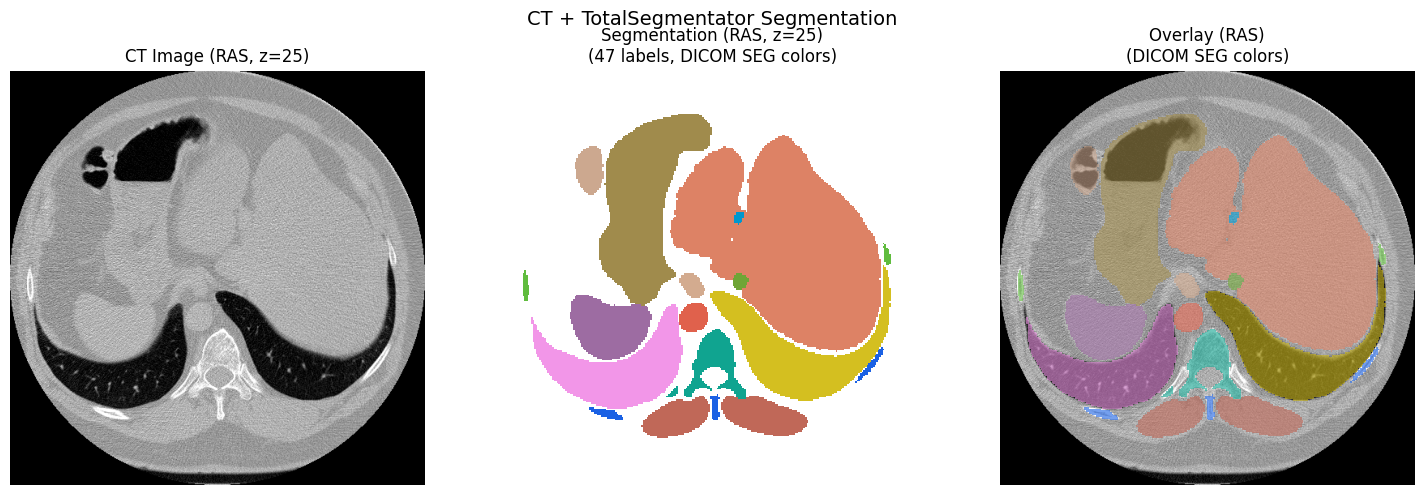


✓ Segmentation loaded with LoadDicomSegd and overlaid after RAS reorientation!
  Colors extracted from DICOM SEG recommendedDisplayRGBValue.


In [33]:
def build_seg_colormap(overlay_info):
    """Build a matplotlib colormap from DICOM SEG segment colors.

    Args:
        overlay_info: Dictionary from LoadDicomSegd containing segmentAttributes

    Returns:
        ListedColormap with colors for each segment label
    """
    segment_attrs = overlay_info.get("segmentAttributes", [[]])

    # Flatten segment attributes (may be nested in groups)
    all_segments = []
    for group in segment_attrs:
        all_segments.extend(group)

    if not all_segments:
        return plt.cm.nipy_spectral

    max_label = max(seg.get("labelID", 0) for seg in all_segments)

    # Build RGBA color array: index 0 = background (transparent)
    colors = np.zeros((max_label + 1, 4))
    colors[0] = [0, 0, 0, 0]  # Background transparent

    for seg in all_segments:
        label_id = seg.get("labelID", 0)
        rgb = seg.get("recommendedDisplayRGBValue", [128, 128, 128])
        colors[label_id] = [rgb[0]/255, rgb[1]/255, rgb[2]/255, 1.0]

    return ListedColormap(colors)

# Build colormap from DICOM SEG metadata
seg_cmap = build_seg_colormap(overlay_info)

# Visualize using RAS-normalized arrays (reoriented in cell above).
# Slices are matched via world coordinates, not raw array indices.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CT image only
axes[0].imshow(ct_np[:, :, z_mid].T, cmap='gray', origin='lower', vmin=-1000, vmax=500)
axes[0].set_title(f'CT Image (RAS, z={z_mid})')
axes[0].axis('off')

# Segmentation only (using DICOM SEG colors)
axes[1].imshow(seg_np[:, :, seg_mid_z].T, cmap=seg_cmap, origin='lower',
               vmin=0, vmax=len(seg_cmap.colors)-1, interpolation='nearest')
axes[1].set_title(f'Segmentation (RAS, z={seg_mid_z})\n({int(seg_np.max())} labels, DICOM SEG colors)')
axes[1].axis('off')

# Overlay — both arrays are in RAS, z-slices matched via world coordinates
axes[2].imshow(ct_np[:, :, z_mid].T, cmap='gray', origin='lower', vmin=-1000, vmax=500)
seg_slice = seg_np[:, :, seg_mid_z]
mask = np.ma.masked_where(seg_slice == 0, seg_slice)
axes[2].imshow(mask.T, cmap=seg_cmap, alpha=0.6, origin='lower',
               vmin=0, vmax=len(seg_cmap.colors)-1, interpolation='nearest')
axes[2].set_title('Overlay (RAS)\n(DICOM SEG colors)')
axes[2].axis('off')

plt.suptitle(f'CT + TotalSegmentator Segmentation', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✓ Segmentation loaded with LoadDicomSegd and overlaid after RAS reorientation!")
print(f"  Colors extracted from DICOM SEG recommendedDisplayRGBValue.")

## 6. Check Licenses

In [16]:
# Always check licenses before use
uid_list = ", ".join(f"'{uid}'" for uid in series_uids)
licenses = client.sql_query(f"""
    SELECT license_short_name, COUNT(*) as count
    FROM index WHERE SeriesInstanceUID IN ({uid_list})
    GROUP BY license_short_name
""")
print("Licenses:")
print(licenses.to_string(index=False))

Licenses:
license_short_name  count
         CC BY 4.0      3


## 7. Cleanup

In [17]:
# import shutil; shutil.rmtree(data_dir)  # Uncomment to delete
print(f"Data at: {data_dir}")

Data at: /tmp/idc_monai_9mmlmi1a


## Summary

This tutorial demonstrated:
1. Querying IDC with `idc-index` SQL interface
2. Downloading DICOM data (no authentication needed)
3. Loading CT images into MONAI with `LoadImaged` and `ITKReader`
4. Finding paired segmentations via `seg_index`
5. Loading DICOM-SEG files with a custom `LoadDicomSegd` transform
6. Extracting segment metadata (names, categories, types, standardized codes)
7. Using DICOM SEG colors for visualization

**Key Point**: DICOM-SEG contains rich metadata. Each segment includes:
- `SegmentLabel` - Human-readable name
- `SegmentedPropertyCategoryCodeSequence` - Category (e.g., "Anatomical Structure")
- `SegmentedPropertyTypeCodeSequence` - Type with standardized codes (SNOMED-CT, etc.)
- `recommendedDisplayRGBValue` - Display color

**Resources:**
- [IDC Portal](https://portal.imaging.datacommons.cancer.gov/)
- [IDC Documentation](https://learn.canceridc.dev/)
- [idc-index](https://github.com/ImagingDataCommons/idc-index)
- [DICOM SEG Standard](https://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_C.8.20.html)
- [ITKWasm DICOM](https://wasm.itk.org/en/latest/introduction/file_formats/dicom.html)